# Neural Network from Scratch
This notebook implements a two-layer neural network using only NumPy to classify 5×6 binary patterns representing letters A, B, and C.

## How This Neural Network Works

This notebook implements a **two‑layer feed‑forward neural network from scratch using only NumPy**.  
The network’s goal is to classify **5×6 binary pixel images of the letters A, B, and C**.

Each 5×6 image is flattened into a **30‑element input vector**. The network has:
- **Input layer — 30 features**
- **Hidden layer — sigmoid activation**
- **Output layer — 3 neurons (A, B, C)**
- **Softmax + cross‑entropy loss**
- **Gradient descent weight updates computed manually (backpropagation)**

### Forward Pass
1. Inputs → Hidden layer
   $( Z_1 = W_1 X + b_1 )$
2. Apply sigmoid
   $( A_1 = \sigma(Z_1) )$
3. Hidden → Output layer
   $( Z_2 = W_2 A_1 + b_2 )$
4. Apply softmax → class probabilities

### Loss
Categorical cross‑entropy compares predictions with one‑hot truth labels.

### Backpropagation
We compute partial derivatives of the loss w.r.t. each parameter and update:
$( W = W - \alpha \cdot \text{gradient} )$

This teaches the network to reduce classification error over epochs.

Because the dataset is tiny and noise‑free, the network quickly reaches **100% accuracy** on A/B/C.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# data

A = np.array([[0,0,1,1,0,0],
              [0,1,0,0,1,0],
              [1,1,1,1,1,1],
              [1,0,0,0,0,1],
              [1,0,0,0,0,1]]).reshape(1,-1)

B = np.array([[0,1,1,1,1,0],
              [0,1,0,0,1,0],
              [0,1,1,1,1,0],
              [0,1,0,0,1,0],
              [0,1,1,1,1,0]]).reshape(1,-1)

C = np.array([[0,1,1,1,1,0],
              [0,1,0,0,0,0],
              [0,1,0,0,0,0],
              [0,1,0,0,0,0],
              [0,1,1,1,1,0]]).reshape(1,-1)

A1 = np.array([[0,0,1,1,0,0],
              [0,1,0,0,1,0],
              [1,1,1,1,1,1],
              [1,0,0,0,0,1],
              [1,1,0,0,1,1]]).reshape(1,-1)

B1 = np.array([[1,1,1,1,1,0],
              [0,1,0,0,1,0],
              [0,1,1,1,1,0],
              [0,1,0,0,1,0],
              [0,1,1,1,1,0]]).reshape(1,-1)

C1 = np.array([[1,1,1,1,1,0],
              [0,1,0,0,0,0],
              [0,1,0,0,0,0],
              [0,1,0,0,0,0],
              [1,1,1,1,1,0]]).reshape(1,-1)

A2 = np.array([[0,0,1,1,0,0],
              [0,1,0,0,1,0],
              [1,1,1,1,1,1],
              [1,0,0,0,0,1],
              [0,0,0,0,0,0]]).reshape(1,-1)

B2 = np.array([[0,1,1,1,1,1],
              [0,1,0,0,1,0],
              [0,1,1,1,1,0],
              [0,1,0,0,1,0],
              [0,1,1,1,1,1]]).reshape(1,-1)

C2 = np.array([[0,1,1,1,1,1],
              [0,1,0,0,0,0],
              [0,1,0,0,0,0],
              [0,1,0,0,0,0],
              [0,1,1,1,1,1]]).reshape(1,-1)

A3 = np.array([[0,0,0,1,0,0],
              [0,1,0,0,1,0],
              [1,1,1,0,1,1],
              [1,0,0,0,0,1],
              [1,0,0,0,0,1]]).reshape(1,-1)

B3 = np.array([[0,1,1,1,1,0],
              [0,1,0,1,1,0],
              [0,1,1,1,1,0],
              [0,1,0,1,1,0],
              [0,1,1,1,1,0]]).reshape(1,-1)

C3 = np.array([[0,1,1,1,1,0],
              [0,1,0,0,0,0],
              [0,1,1,0,0,0],
              [1,1,0,0,0,0],
              [0,1,1,1,1,0]]).reshape(1,-1)

A4 = np.array([[0,0,1,1,0,0],
              [0,1,0,0,1,0],
              [1,1,1,1,1,1],
              [0,0,0,0,0,1],
              [1,0,0,0,1,1]]).reshape(1,-1)

B4 = np.array([[0,1,1,1,0,0],
              [0,1,0,0,1,0],
              [0,1,1,1,1,1],
              [0,1,0,0,1,0],
              [0,1,1,1,1,0]]).reshape(1,-1)

C4 = np.array([[0,1,1,1,1,0],
              [0,1,0,0,0,0],
              [1,1,0,0,0,1],
              [0,1,0,0,0,0],
              [0,1,1,1,1,0]]).reshape(1,-1)

A6 = np.array([[0,0,1,1,0,0],
              [0,1,0,0,1,0],
              [0,1,1,1,1,0],
              [1,0,0,0,0,1],
              [1,0,0,0,0,1]]).reshape(1,-1)

B6 = np.array([[0,0,1,1,1,0],
              [0,1,0,0,1,0],
              [0,1,1,1,1,0],
              [0,1,1,0,1,0],
              [0,1,1,1,1,0]]).reshape(1,-1)

C6 = np.array([[1,1,1,1,1,0],
              [0,1,0,0,0,0],
              [0,1,0,0,0,0],
              [0,1,0,0,0,0],
              [1,1,1,1,1,0]]).reshape(1,-1)

A5 = np.array([[1,0,1,1,0,0],
              [0,1,0,0,1,0],
              [1,1,1,1,1,1],
              [1,0,0,0,0,1],
              [1,0,0,0,0,0]]).reshape(1,-1)

B5 = np.array([[1,1,1,1,1,0],
              [0,1,0,0,1,0],
              [0,1,1,1,1,0],
              [0,1,0,0,1,0],
              [1,1,1,1,1,0]]).reshape(1,-1)

C5 = np.array([[0,1,1,1,1,0],
              [0,1,0,1,0,0],
              [0,1,0,0,0,0],
              [0,1,0,1,0,0],
              [0,1,1,1,1,0]]).reshape(1,-1)

X = np.array([A,B,C,A2,B2,C2,A3,B3,C3,A4,B4,C4,A5,B5,C5,A6,B6,C6])

# label
Y = np.array([[1,0,0],
              [0,1,0],
              [0,0,1],[1,0,0],
              [0,1,0],
              [0,0,1],[1,0,0],
              [0,1,0],
              [0,0,1],[1,0,0],
              [0,1,0],
              [0,0,1],[1,0,0],
              [0,1,0],
              [0,0,1],[1,0,0],
              [0,1,0],
              [0,0,1],[1,0,0],
              [0,1,0],
              [0,0,1]])

# data set
data_set = list(zip(X,Y))

In [3]:



# layer
class Layer_Dense:
    def __init__(self, n_inputs, n_neurons):
        self.weights = 0.10 * np.random.randn(n_neurons, n_inputs)
        self.biases = np.zeros((n_neurons, 1))

    def forward(self, inputs):
        self.outputs = np.dot(self.weights, inputs) + self.biases


# activation function
class sigmoid_activation:
    def forward(self, inputs):
        self.outputs = 1 / (1 + np.exp(-inputs))


class softmax_activation:
    def forward(self, inputs):
        exp = np.exp(inputs - np.max(inputs, axis=0, keepdims=True))
        self.outputs = exp / np.sum(exp, axis=0, keepdims=True)


# model
layer1 = Layer_Dense(30, 5)
layer2 = Layer_Dense(5, 3)
activation1 = sigmoid_activation()
activation2 = softmax_activation()


# cross-entropy loss
def loss(yhat, y):
    yhat = np.clip(yhat, 1e-12, 1 - 1e-12)
    return -np.sum(y * np.log(yhat))


# forward propagation
def forward_prop(x):
    layer1.forward(x.T)
    activation1.forward(layer1.outputs)
    layer2.forward(activation1.outputs)
    activation2.forward(layer2.outputs)
    return activation2.outputs


# back propagation
def backprop(x, y):
    forward_prop(x)
    dl_dz2 = activation2.outputs - y
    dl_dz1 = np.dot(layer2.weights.T, dl_dz2) * (activation1.outputs * (1 - activation1.outputs))
    dl_dw2 = np.dot(dl_dz2, activation1.outputs.T)
    dl_db2 = dl_dz2
    dl_dw1 = np.dot(dl_dz1, x)
    dl_db1 = dl_dz1
    return (dl_dw2, dl_db2, dl_dw1, dl_db1)


# train
def train(data_set, alpha=0.3, epochs=500):
    cost_history = []
    for i in range(epochs):
        cost = []
        dl_dw2, dl_db2, dl_dw1, dl_db1 = [], [], [], []

        for x, y in data_set:
            yhat = forward_prop(x)
            cost.append(loss(yhat.reshape(-1), y))
            derivatives = backprop(x, y.reshape(3, 1))
            dl_dw2.append(derivatives[0])
            dl_db2.append(derivatives[1])
            dl_dw1.append(derivatives[2])
            dl_db1.append(derivatives[3])

        cost_history.append(np.mean(cost))
        print(f"Epoch: {i + 1}   Loss: {np.mean(cost):.6f}")

        layer1.weights -= alpha * np.mean(dl_dw1, axis=0)
        layer1.biases  -= alpha * np.mean(dl_db1, axis=0)
        layer2.weights -= alpha * np.mean(dl_dw2, axis=0)
        layer2.biases  -= alpha * np.mean(dl_db2, axis=0)

    return cost_history


# prediction
def predict(x):
    return forward_prop(x)


In [4]:
cost_history = train(data_set, 0.3, 1000)

Epoch: 1   Loss: 1.112401
Epoch: 2   Loss: 1.107607
Epoch: 3   Loss: 1.104132
Epoch: 4   Loss: 1.101362
Epoch: 5   Loss: 1.098973
Epoch: 6   Loss: 1.096781
Epoch: 7   Loss: 1.094676
Epoch: 8   Loss: 1.092586
Epoch: 9   Loss: 1.090460
Epoch: 10   Loss: 1.088256
Epoch: 11   Loss: 1.085937
Epoch: 12   Loss: 1.083470
Epoch: 13   Loss: 1.080821
Epoch: 14   Loss: 1.077957
Epoch: 15   Loss: 1.074843
Epoch: 16   Loss: 1.071444
Epoch: 17   Loss: 1.067723
Epoch: 18   Loss: 1.063643
Epoch: 19   Loss: 1.059166
Epoch: 20   Loss: 1.054251
Epoch: 21   Loss: 1.048862
Epoch: 22   Loss: 1.042958
Epoch: 23   Loss: 1.036505
Epoch: 24   Loss: 1.029467
Epoch: 25   Loss: 1.021815
Epoch: 26   Loss: 1.013524
Epoch: 27   Loss: 1.004573
Epoch: 28   Loss: 0.994952
Epoch: 29   Loss: 0.984657
Epoch: 30   Loss: 0.973696
Epoch: 31   Loss: 0.962084
Epoch: 32   Loss: 0.949849
Epoch: 33   Loss: 0.937029
Epoch: 34   Loss: 0.923671
Epoch: 35   Loss: 0.909832
Epoch: 36   Loss: 0.895574
Epoch: 37   Loss: 0.880968
Epoch: 38 

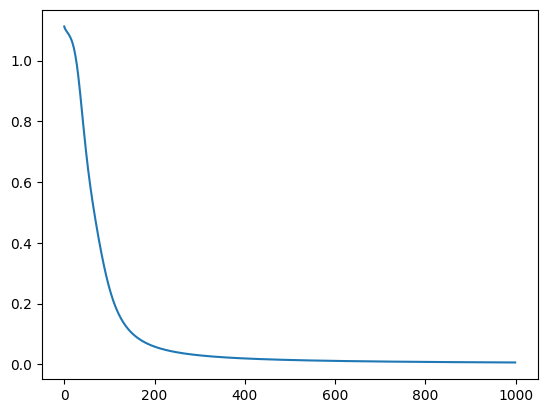

In [5]:
plt.plot(cost_history)

In [6]:
labels = ["A","B","C"]

correct = 0
for x, y in data_set:
    probs = predict(x).reshape(-1)
    pred = np.argmax(probs)
    true = np.argmax(y)

    print("probs:", probs.round(3), 
          " predicted:", labels[pred], 
          " true:", labels[true])

    if pred == true:
        correct += 1

print("Accuracy:", correct / len(data_set))


probs: [0.998 0.001 0.001]  predicted: A  true: A
probs: [0.002 0.993 0.006]  predicted: B  true: B
probs: [0.001 0.006 0.993]  predicted: C  true: C
probs: [0.996 0.003 0.001]  predicted: A  true: A
probs: [0.002 0.992 0.006]  predicted: B  true: B
probs: [0.001 0.005 0.993]  predicted: C  true: C
probs: [0.998 0.001 0.001]  predicted: A  true: A
probs: [0.002 0.992 0.006]  predicted: B  true: B
probs: [0.002 0.007 0.991]  predicted: C  true: C
probs: [0.996 0.003 0.001]  predicted: A  true: A
probs: [0.003 0.991 0.006]  predicted: B  true: B
probs: [0.002 0.004 0.994]  predicted: C  true: C
probs: [0.997 0.002 0.001]  predicted: A  true: A
probs: [0.002 0.991 0.006]  predicted: B  true: B
probs: [0.001 0.006 0.993]  predicted: C  true: C
probs: [0.996 0.004 0.001]  predicted: A  true: A
probs: [0.002 0.993 0.005]  predicted: B  true: B
probs: [0.002 0.005 0.993]  predicted: C  true: C
Accuracy: 1.0


probs: [0.981 0.017 0.002]  predicted: A


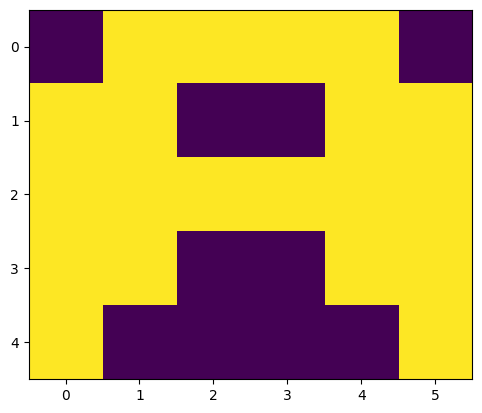

In [7]:
a = np.array([[0,1,1,1,1,0],
              [1,1,0,0,1,1],
              [1,1,1,1,1,1],
              [1,1,0,0,1,1],
              [1,0,0,0,0,1]]).reshape(1,-1)

probs = predict(a).reshape(-1)
pred = np.argmax(probs)
print("probs:", probs.round(3), " predicted:", labels[pred])
plt.imshow(a.reshape(5,6))